### Simple Linear Regression
With one independent variable

In [1]:
# import necessary librarzies
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import sys
sys.path.append("..")
from utils import MSE

In [3]:
# Generate random data
X = np.linspace(1, 20, 200)
noise = np.random.random(200)
m ,c =0.5,3 
y = X*m+c+noise

Text(0, 0.5, 'y')

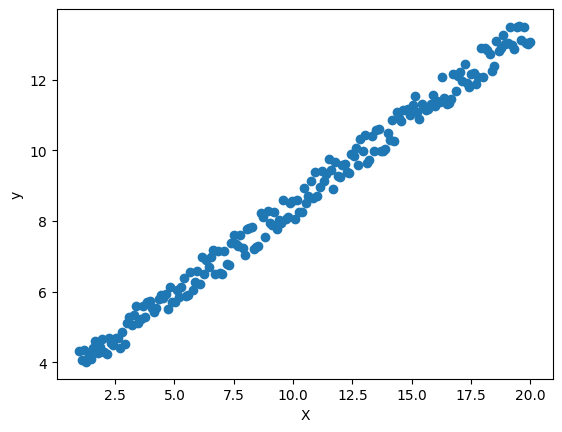

In [4]:
# Visualize the data
plt.scatter(X,y)
plt.xlabel("X")
plt.ylabel("y")

In [5]:
# predict function and MSE function
predict = lambda X,m,c: X*m +c

In [6]:
# we will see the effect of m and c on the cost function, so we will generate a range of vlue for m and c
m_test = np.linspace(-5,8,30)
c_test =np.linspace(-5,10,30)

# we use the real vlues of m and c to see how the cost function changes with respect to m and c,
pred_m = np.array([predict(X,_,c) for _ in m_test]) 
pred_c = np.array([predict(X,m,_) for _ in c_test])

# calculate the cost function for each value of m and c
cost_over_m = np.array([MSE(y,_)for _ in pred_m]) 
cost_over_c = np.array([MSE(y,_)for _ in pred_c]) 


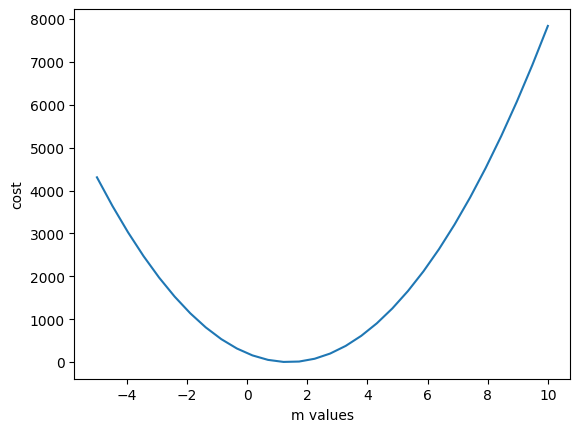

Text(0, 0.5, 'cost')

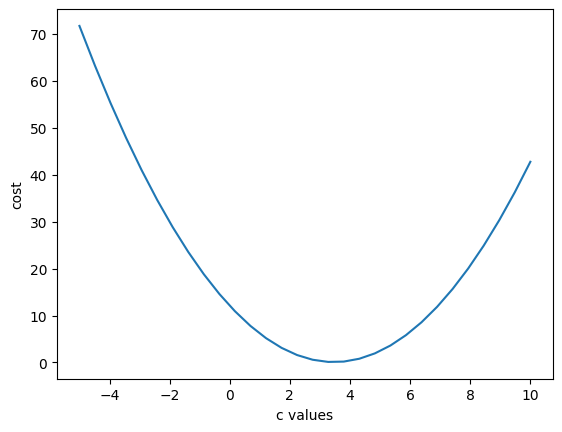

In [7]:
# visualize the cost function with respect to m and c
plt.plot(c_test,cost_over_m)
plt.xlabel("m values")
plt.ylabel("cost")
plt.show()
plt.plot(c_test,cost_over_c)
plt.xlabel("c values")
plt.ylabel("cost")

As we see The **Cost** (which depends on these parameters) decreases as **m** and **c** value gets **closer** to the true value.

In this example, we already know the range of values where the true parameters belong, but in the **real world**, we don't. Therefore, we need an algorithm that can **efficiently predict** the optimal values for **m** and **c**.

The algorithm we will use is **Gradient Descent**. The idea behind it is straightforward: it uses **Partial Derivatives**. 

**Why do we use derivatives?** In reality, a derivative represents the **rate of change** of a function with respect to a specific parameters(**m** or **c**). This is exactly what we need: to know how the **Cost Function** changes when **m** and **c** change.

**Why the Cost Function?** We aren't searching for values that make the prediction "perfect" instantly; we want to find **m** and **c** that make the **difference** between the real value and the predicted value as **minimum** as possible. This "difference" is what defines our Cost Function.

**Gradient Descent**is primarily based on **partial derivatives**. The algorithm performs a series of iterations (updates) to determine the direction of optimization. A key factor here is the Learning Rate ($\alpha$), which determines the size of the "step" or "jump" taken in that direction.Choosing an inappropriate learning rate can lead to poor performance: if it's too large, the model may overshoot the minimum and fail to converge. Conversely, if it's too small, the algorithm will take an extremely long time to reach the optimal results

$$m = m - \alpha \cdot \frac{\partial J}{\partial m}$$ $$c = c - \alpha \cdot \frac{\partial J}{\partial c}$$ $$\frac{\partial J}{\partial m} = \frac{-2}{n} \sum_{i=1}^{n} X_i (y_i - \hat{y}_i)$$ $$\frac{\partial J}{\partial c} = \frac{-2}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)$$

In [8]:
def gradientDescent(X,y,learning_rate,epochs):
    n = len(y)
    m,c=0,0
    cost = []
    for i in range(epochs):
        pred = predict(X,m,c)
        error = pred - y
        m = m-(2/n)*learning_rate *sum(error*X)
        c = c-(2/n)*learning_rate *sum(error)
        cost.append(MSE(y,pred))
    return m,c,np.array(cost)
    

In [9]:
# run the gradient descent algorithm and print the final values of m and c, and the cost function over epochs
m_result,c_result,cost = gradientDescent(X,y,0.001,5000)
print(f"Final values of m: {m_result},and c: {c_result}")
print(f"Final cost: {cost[-1]}")

Final values of m: 0.5288155410692601,and c: 3.0772414405957513
Final cost: 0.1077765329427876


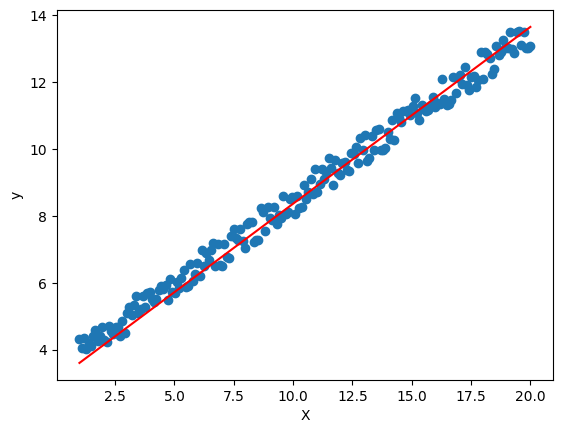

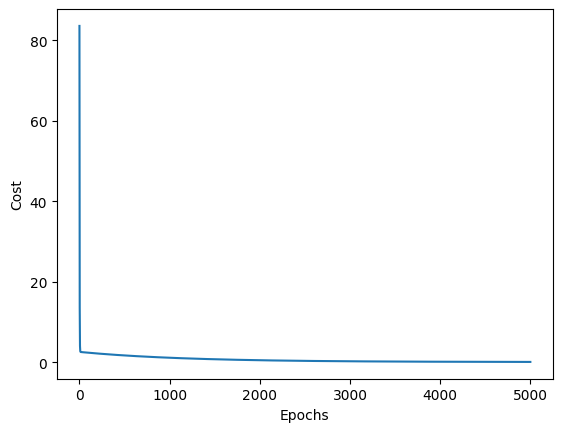

In [10]:
# visualize the data and the regression line and the cost function over epochs
plt.scatter(X,y)
plt.xlabel("X")
plt.ylabel("y")
plt.plot(X,predict(X,m_result,c_result),color="red")
plt.show()
plt.plot(cost)
plt.xlabel("Epochs")
plt.ylabel("Cost")
plt.show()


"We can see that the final values of m and c are very close to the true values we defined. The resulting regression line fits the data perfectly. Furthermore, the cost function clearly decreases over the epochs, confirming that the model is learning."